# Week 2 - Day 8
# Feature Engineering: Encoding, Scaling & Transformation

## Internship Task Overview

Feature Engineering is one of the most important stages in the Machine Learning pipeline. Raw datasets often contain categorical values, unscaled numerical features, and information that cannot be directly understood by machine learning algorithms.

The goal of this task is to transform raw data into a machine-learning-ready format through:

- Categorical Encoding
- Feature Creation
- Feature Scaling
- Feature Documentation

### Dataset

Marketing Campaign Dataset

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

### Objectives

- Encode categorical variables
- Create meaningful features
- Scale numerical data
- Prepare data for machine learning
- Document all final features

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Dataset Loading

The dataset is loaded using Pandas.

This step helps us understand:

- Number of rows
- Number of columns
- Data types
- Available features

Before performing feature engineering, it is important to inspect the dataset structure.

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Identifying Categorical Features

Machine learning models cannot directly understand text values.

Therefore categorical columns must be converted into numerical form.

We first identify all object-type columns present in the dataset.

In [3]:
categorical_cols = df.select_dtypes(include="object").columns

print(categorical_cols)

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='str')


C:\Users\Maryam\AppData\Local\Temp\ipykernel_23168\343913642.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


# Categorical Encoding

## What is Encoding?

Encoding converts categorical text values into numerical representations.

### Encoding Method Used

One-Hot Encoding

### Why One-Hot Encoding?

The columns:

- Education
- Marital_Status

are nominal categories with no natural order.

Therefore One-Hot Encoding is the most appropriate method.

The parameter `drop_first=True` is used to avoid the Dummy Variable Trap.

In [4]:
df_encoded = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=True
)

print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (2240, 29)
Encoded Shape: (2240, 38)


# Feature Creation

Creating new features often improves model performance.

Instead of relying only on raw columns, we can generate more meaningful variables that better represent customer behavior.

The following engineered features will be created:

1. Total Spending
2. Total Children
3. Age
4. Income Per Person

In [5]:
df_encoded['Total_Spending'] = (
    df_encoded['MntWines']
    + df_encoded['MntFruits']
    + df_encoded['MntMeatProducts']
    + df_encoded['MntFishProducts']
    + df_encoded['MntSweetProducts']
    + df_encoded['MntGoldProds']
)

# Feature 1: Total Spending

## Purpose

This feature represents the total amount spent by a customer across all product categories.

## Business Importance

This feature helps identify:

- High-value customers
- Medium-value customers
- Low-value customers

It provides a complete view of customer purchasing behavior.

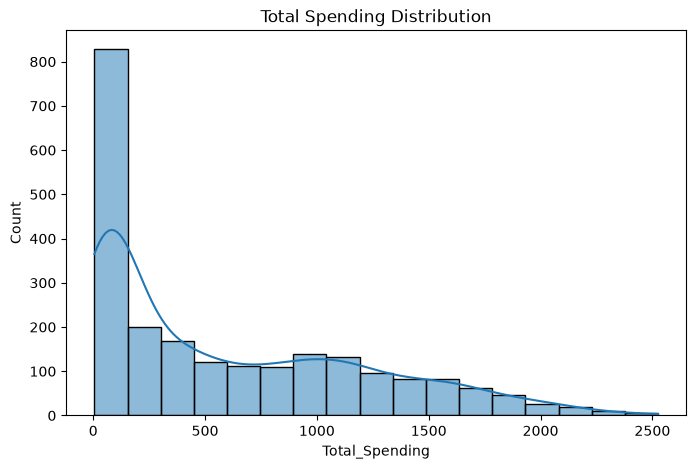

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_encoded['Total_Spending'],
    kde=True
)

plt.title("Total Spending Distribution")

plt.savefig(
    "outputs/total_spending_distribution.png"
)

plt.show()

# Total Spending Distribution Analysis

## Observation

Most customers belong to the low-to-medium spending category.

A small number of customers have significantly higher spending values.

This creates a right-skewed distribution.

## Insight

Customers with higher spending values may be targeted for premium marketing campaigns and loyalty programs.

## Conclusion

Total Spending is a strong feature that captures overall customer value.

In [7]:
df_encoded['Total_Children'] = (
    df_encoded['Kidhome']
    + df_encoded['Teenhome']
)

df_encoded['Age'] = 2025 - df_encoded['Year_Birth']

df_encoded['Income_Per_Person'] = (
    df_encoded['Income']
    /
    (df_encoded['Total_Children'] + 1)
)

# Additional Engineered Features

## Total Children

Represents the total number of children in a household.

## Age

Created from Year_Birth to better represent customer demographics.

## Income Per Person

Represents the available income per family member.

This provides a more realistic view of purchasing power.

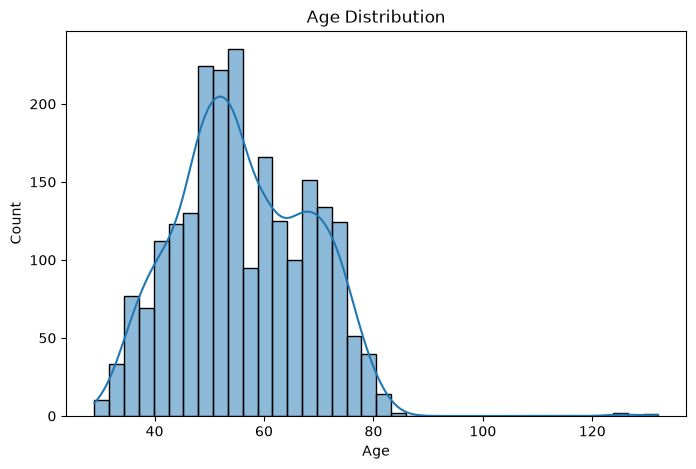

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_encoded['Age'],
    kde=True
)

plt.title("Age Distribution")

plt.savefig(
    "outputs/age_distribution.png"
)

plt.show()

# Age Distribution Analysis

## Observation

The majority of customers fall into the middle-age category.

The age distribution is relatively balanced.

## Insight

Age can significantly influence:

- Spending behavior
- Product preferences
- Campaign responses

## Conclusion

Age is an important demographic feature and may contribute significantly to predictive modeling.

# Train-Test Split

Before scaling, the dataset is divided into:

- Training Data
- Testing Data

This prevents data leakage and ensures fair model evaluation.

The target variable used is:

Response

In [9]:
X = df_encoded.drop('Response', axis=1)

y = df_encoded['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Feature Scaling

## Why Scaling?

Machine learning algorithms are sensitive to feature magnitudes.

Example:

Age = 18–80

Income = 10,000–100,000

Without scaling, larger values can dominate model learning.

### Scaling Method Used

StandardScaler

StandardScaler transforms data so that:

- Mean ≈ 0
- Standard Deviation ≈ 1

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [11]:
print(X_train.dtypes)

ID                           int64
Year_Birth                   int64
Income                     float64
Kidhome                      int64
Teenhome                     int64
Dt_Customer                    str
Recency                      int64
MntWines                     int64
MntFruits                    int64
MntMeatProducts              int64
MntFishProducts              int64
MntSweetProducts             int64
MntGoldProds                 int64
NumDealsPurchases            int64
NumWebPurchases              int64
NumCatalogPurchases          int64
NumStorePurchases            int64
NumWebVisitsMonth            int64
AcceptedCmp3                 int64
AcceptedCmp4                 int64
AcceptedCmp5                 int64
AcceptedCmp1                 int64
AcceptedCmp2                 int64
Complain                     int64
Z_CostContact                int64
Z_Revenue                    int64
Education_Basic               bool
Education_Graduation          bool
Education_Master    

In [12]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1792 entries, 792 to 860
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       1792 non-null   int64  
 1   Year_Birth               1792 non-null   int64  
 2   Income                   1773 non-null   float64
 3   Kidhome                  1792 non-null   int64  
 4   Teenhome                 1792 non-null   int64  
 5   Dt_Customer              1792 non-null   str    
 6   Recency                  1792 non-null   int64  
 7   MntWines                 1792 non-null   int64  
 8   MntFruits                1792 non-null   int64  
 9   MntMeatProducts          1792 non-null   int64  
 10  MntFishProducts          1792 non-null   int64  
 11  MntSweetProducts         1792 non-null   int64  
 12  MntGoldProds             1792 non-null   int64  
 13  NumDealsPurchases        1792 non-null   int64  
 14  NumWebPurchases          1792 non-null 

In [13]:
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d-%m-%Y'
)

In [15]:
df['Customer_Days'] = (
    pd.Timestamp.today() - df['Dt_Customer']
).dt.days

In [16]:
df.drop('Dt_Customer', axis=1, inplace=True)

In [17]:
X = df.drop('Response', axis=1)
y = df['Response']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert categorical columns into numeric
df = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=True
)

# Features and Target
X = df.drop('Response', axis=1)
y = df['Response']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data encoded and scaled successfully!")
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

✅ Data encoded and scaled successfully!
X_train shape: (1792, 37)
X_test shape: (448, 37)


In [21]:
print(
    "Mean:",
    np.mean(X_train_scaled[:,0])
)

print(
    "Std:",
    np.std(X_train_scaled[:,0])
)

Mean: -1.214306433183765e-16
Std: 1.0


# Scaling Verification

## Observation

After scaling:

- Mean is approximately 0
- Standard deviation is approximately 1

This confirms that StandardScaler has successfully standardized the feature values.

## Conclusion

The dataset is now ready for machine learning model training.

# Final Feature Summary

To maintain proper documentation, a feature summary table is created.

The table contains:

- Feature Name
- Data Type
- Original or Engineered Feature

This improves project readability and future maintenance.

In [22]:
feature_summary = pd.DataFrame({
    "Feature": df_encoded.columns,
    "Data Type": df_encoded.dtypes.astype(str)
})

feature_summary['Type'] = 'Original'

engineered_features = [
    'Total_Spending',
    'Total_Children',
    'Age',
    'Income_Per_Person'
]

feature_summary.loc[
    feature_summary['Feature'].isin(engineered_features),
    'Type'
] = 'Engineered'

feature_summary.head(20)

,Feature,Data Type,Type
ID,ID,int64,Original
Year_Birth,Year_Birth,int64,Original
Income,Income,float64,Original
Kidhome,Kidhome,int64,Original
Teenhome,Teenhome,int64,Original
Dt_Customer,Dt_Customer,str,Original
Recency,Recency,int64,Original
MntWines,MntWines,int64,Original
MntFruits,MntFruits,int64,Original
MntMeatProducts,MntMeatProducts,int64,Original


# Conclusion

In this task, Feature Engineering techniques were successfully applied to the Marketing Campaign dataset.

The workflow included:

- Categorical Encoding
- Feature Creation
- Feature Scaling
- Feature Documentation

Several meaningful features such as Total Spending, Age, Total Children, and Income Per Person were engineered to improve data representation.

The dataset is now prepared for future Machine Learning tasks including correlation analysis, hypothesis testing, and predictive model development.